In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl

import warnings
warnings.filterwarnings("ignore")

In [22]:
df = pd.read_excel("dataset/Customer-Purchase-History.xlsx")
df.head(10)

,CustomerID,Product,PurchaseDate,Quantity,UnitPrice,CustomerName,ProductCategory,PaymentMethod,ReviewRating,TotalPrice
0,C5361,Phone,2024-03-05,8,618.83,Customer C5361,Office Supplies,Cash,1,4950.64
1,C6231,Laptop,2025-06-21,7,366.22,Customer C6231,Electronics,Debit Card,3,2563.54
2,C7704,Chair,2023-06-25,5,634.51,Customer C7704,Office Supplies,Credit Card,4,3172.55
3,C2923,Printer,2023-09-30,3,508.63,Customer C2923,Office Supplies,Gift Card,1,1525.89
4,C4847,Monitor,2023-04-03,4,452.06,Customer C4847,Electronics,Credit Card,2,1808.24
5,C7317,Chair,2023-04-11,3,209.79,Customer C7317,Office Supplies,Gift Card,1,629.37
6,C5076,Desk,2024-06-19,3,88.74,Customer C5076,Office Supplies,Debit Card,3,266.22
7,C5181,Chair,2023-08-16,8,273.92,Customer C5181,Furniture,Credit Card,2,2191.36
8,C9564,Monitor,2023-02-11,6,718.79,Customer C9564,Electronics,Gift Card,3,4312.74
9,C7521,Tablet,2025-06-14,7,100.37,Customer C7521,Office Supplies,Debit Card,4,702.59


In [23]:
df.columns

Index(['CustomerID', 'Product', 'PurchaseDate', 'Quantity', 'UnitPrice',
       'CustomerName', 'ProductCategory', 'PaymentMethod', 'ReviewRating',
       'TotalPrice'],
      dtype='object')

In [6]:
df.shape

(1800, 10)

In [7]:
df.isnull().sum()

CustomerID         0
Product            0
PurchaseDate       0
Quantity           0
UnitPrice          0
CustomerName       0
ProductCategory    0
PaymentMethod      0
ReviewRating       0
TotalPrice         0
dtype: int64

In [14]:
df["Product"].value_counts()

Product
Laptop     280
Tablet     278
Desk       256
Monitor    254
Chair      253
Phone      246
Printer    233
Name: count, dtype: int64

In [49]:
df["ProductCategory"].value_counts()

ProductCategory
Electronics        606
Office Supplies    597
Furniture          597
Name: count, dtype: int64

# Sales Performance & Revenue

##### 1- Which product categories and individual products are the primary drivers of revenue, and how concentrated is revenue among top-performing products?

<p><b>Strategic Value:</b> Identifies the products/categories that deserve greater inventory, marketing, and management attention while revealing dependency on a small number of products.</p>

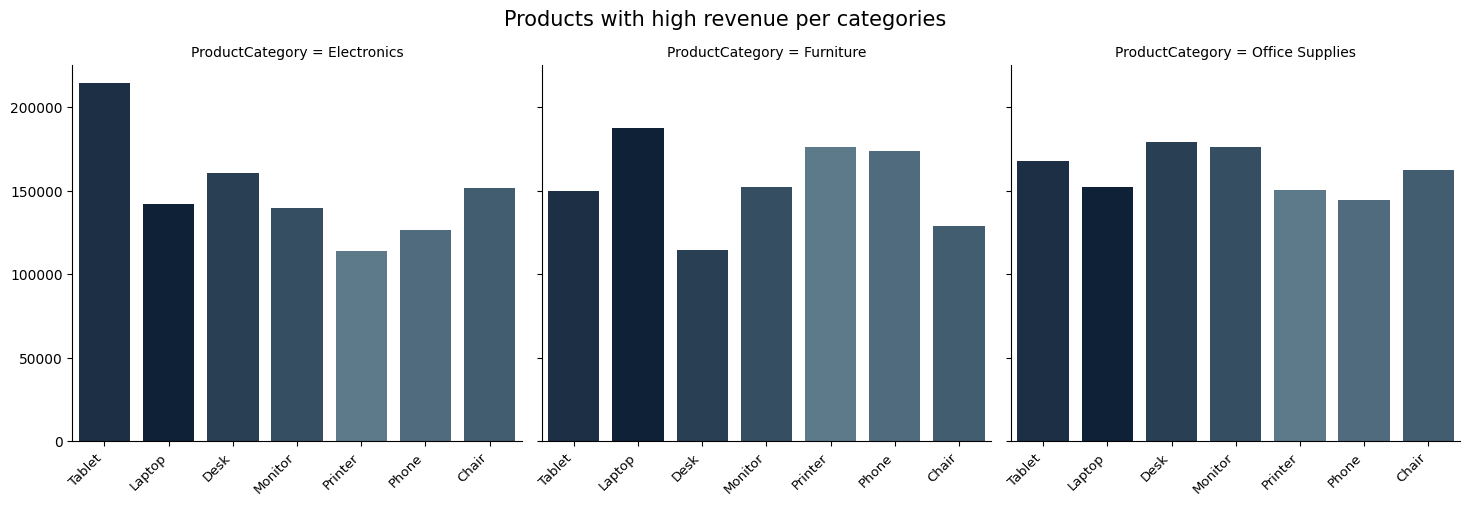

In [90]:
product = df.groupby(["ProductCategory","Product"], as_index=False)["TotalPrice"].sum()
product = product.sort_values(by="TotalPrice", ascending=False).reset_index(drop=True)




colors = {
    "Laptop" : "#08203E",
    "Tablet" : "#152F4C",
    "Desk" : "#223F5A",
    "Monitor" : "#2F4E69",
    "Chair" : "#3B5D77",
    "Phone" : "#486D85",
    "Printer" : "#557C93"
}
ax = sns.catplot(data=product, kind="bar", x="Product",
                 y="TotalPrice", col="ProductCategory",
                 palette=colors)
ax.set_xlabels("")
ax.set_ylabels("")
ax.set_xticklabels(fontsize=9.5, rotation=45, horizontalalignment='right')
ax.fig.subplots_adjust(top=0.87)
ax.fig.suptitle('Products with high revenue per categories', fontsize=15)

plt.show()

In [89]:
product = (
    df.groupby(["ProductCategory", "Product"], as_index=False)["TotalPrice"]
      .sum()
      .sort_values("TotalPrice", ascending=False)
)

product["RevenueShare"] = (
    product["TotalPrice"] / product["TotalPrice"].sum()
)

product["RevenueShare"] *= 100

product["CumulativeShare"] = product["RevenueShare"].cumsum()

product

,ProductCategory,Product,TotalPrice,RevenueShare,CumulativeShare
6,Electronics,Tablet,214888.84,6.578250,6.578250
9,Furniture,Laptop,187734.37,5.746988,12.325238
15,Office Supplies,Desk,179330.53,5.489727,17.814964
17,Office Supplies,Monitor,176356.56,5.398687,23.213651
12,Furniture,Printer,176330.12,5.397877,28.611528
11,Furniture,Phone,173571.13,5.313418,33.924946
20,Office Supplies,Tablet,168121.28,5.146585,39.071531
14,Office Supplies,Chair,162324.90,4.969145,44.040676
1,Electronics,Desk,160389.32,4.909892,48.950568
10,Furniture,Monitor,152454.28,4.666982,53.617550


##### 2- How has sales revenue and sales volume evolved over time, and are there statistically meaningful periods of growth or decline?

<p><b>Strategic Value:</b> Reveals business growth patterns, seasonality, demand changes, and periods requiring investigation or intervention.</p>

##### 3- Which products generate high revenue but low sales volume, and which generate high volume but relatively low revenue?

<p><b>Strategic Value:</b> Helps distinguish premium/high-value products from volume-driven products and supports differentiated pricing and inventory strategies.</p>